In [1]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================

#I want to load the data among the group PATIENTS and for exemple i want to begin the read the file for Patient 00 
# as an exemple knowing that for each patients we have data at right and left (exemple : Test 00 the files are name : Data_Ch_D.csv and Data_Ch_G.csv)
#  and for each file we have the data for 1 K-Push and 2  K-Move. I want to extract the data for K-Push and K-Move separately 
# and also to extract the baseline values for each sensor (wrist and shoulder) that are given in the file before the data of K-Move. I want to do this for all the files of all the patients.  
# I want to create a function that will take as input the name of the file and will return the data for K-Push, K-Move and the baseline values for each sensor. I want to do this for all the files of all the patients.
# I want to check if the data is correctly extracted by printing the first 5 rows of each dataframe and the baseline values for each sensor. I want to do this for all the files of all the patients.
# I want to create a main script that will call the function for each file and will store the results in a dictionary. I want to do this for all the files of all the patients.
# I want to create a function that will take as input the name of the file and will return the data for K-Push, K-Move and the baseline values for each sensor. I want to do this for all the files of all the patients.
# I want to check if the data is correctly extracted by printing the first 5 rows of each dataframe and the baseline values for each sensor. I want to do this for all the files of all the patients.
# I want to create a main script that will call the function for each file and will store the results in a dictionary. I want to do this for all the files of all the patients.

Patients = ["Data_Ch_D", "Data_Ch_G",  # it s for the data of the patient 00  which is the data names Data_Ch_D.csv and Data_Ch_G.csv
            # "Test_01_D", "Test_01_G",  # it s for the data of the patient 01 
            # "Test_02_D", "Test_02_G",  # it s for the data of the patient 02 
            # "Test_03_D", "Test_03_G"]  # it s for the data of the patient 03
         
def load_data (filename): 

    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)


    # ---------- STEP 2 : FIND K-PUSH and K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None
    for i, line in enumerate(lines):
        if "K-Push" in line and idx_push is None:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push is None:
        print("❌ K-PUSH NOT FOUND")
        return None, None, None, None
    if idx_move is None:
        print("❌ K-MOVE NOT FOUND")
        return None, None, None, None

    # ---------- STEP 3 - SPLIT BLOCKS (ORDER INDEPENDENT) ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        move_lines = lines[idx_move:idx_push]
        push_lines = lines[idx_push:]


    # ---------- STEP 4: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
       try:
        header_idx_push = next(i for i, line in enumerate(push_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Push non trouvé")
        return None, None, None, None

    
    push_str = "".join(push_lines[header_idx_push:])
    df_push = pd.read_csv(StringIO(push_str), sep=r"\t|,", engine="python", on_bad_lines="skip")
    df_push = df_push.dropna(axis=1, how='all')
    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    if "time" in df_push.columns and "force" in df_push.columns:
        df_push = df_push[["time", "force"]]
        df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()
    else:
        df_push = pd.DataFrame()    


    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}
    for line in lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue
            values = values[:4]
            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values



# ---------- STEP 6 - CLEAN K-MOVE ----------
    try:
        header_idx_move = next(i for i, line in enumerate(move_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Move non trouvé")
        return df_push, pd.DataFrame(), pd.DataFrame(), baseline

    move_data_lines = move_lines[header_idx_move + 1:]
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.replace("", np.nan).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- EXTRACT SENSORS ----------
    try:
        df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
        df_wrist.columns = ["time","qx","qy","qz","qw"]
        df_shoulder = df_move.iloc[:, [0,5,6,7,8]].copy()
        df_shoulder.columns = ["time","qx","qy","qz","qw"]
    except:
        df_wrist = pd.DataFrame()
        df_shoulder = pd.DataFrame()

    # ---------- RETURN ----------
    return df_push, df_wrist, df_shoulder, baseline
]


# ==========================================================
# MAIN SCRIPT
# ==========================================================
filename = ["Data_Ch_1.csv", "Data_Ch_2.csv"]  # liste des fichiers

results = {}

for file in filename:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)
    results[file] = {"push": df_push, "wrist": df_wrist, "shoulder": df_shoulder, "baseline": baseline}

    # ---------- FULL DISPLAY ----------
    print(f"\n===== FILE: {file} =====")
    print("\nK-Push:\n", df_push.head())
    print("\nWrist (S121577):\n", df_wrist.head())
    print("\nShoulder (S121578):\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline.get("wrist", []))
    print("Baseline shoulder:", baseline.get("shoulder", []))
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)




SyntaxError: invalid syntax (263758193.py, line 27)

In [1]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_Ch_D.csv"]  # for single files

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }


# ==========================================================
# EXAMPLES
# ==========================================================

# Example: access wrist data
# df_wrist_example = results["Data_GG.csv"]["wrist"]

# Example: compare datasets
# print(results["Data_droite.csv"]["wrist"].shape)
# print(results["Data_GG.csv"]["wrist"].shape)


===== FILE: Data_Ch_D.csv =====
K-Push:
     time  force
0  0.000    0.0
1  0.001    0.0
2  0.002    0.0
3  0.003    0.0
4  0.004    0.0

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000  0.396362  0.516846  0.433289  0.622803
1  0.004  0.396376  0.516894  0.433273  0.622825
2  0.008  0.396373  0.516982  0.433239  0.622789
3  0.012  0.396370  0.517070  0.433206  0.622754
4  0.016  0.396342  0.517134  0.433178  0.622728

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000 -0.573059  0.038269  0.100220  0.812439
1  0.004 -0.573072  0.038239  0.100222  0.812427
2  0.008 -0.573105  0.038179  0.100222  0.812400
3  0.012 -0.573163  0.038148  0.100252  0.812365
4  0.016 -0.573195  0.038117  0.100283  0.812336

Baseline wrist: [0.383, 0.513, 0.399, 0.656]
Baseline shoulder: [-0.568, 0.031, 0.1, 0.816]

Shapes: (47382, 2) (11835, 5) (11835, 5)


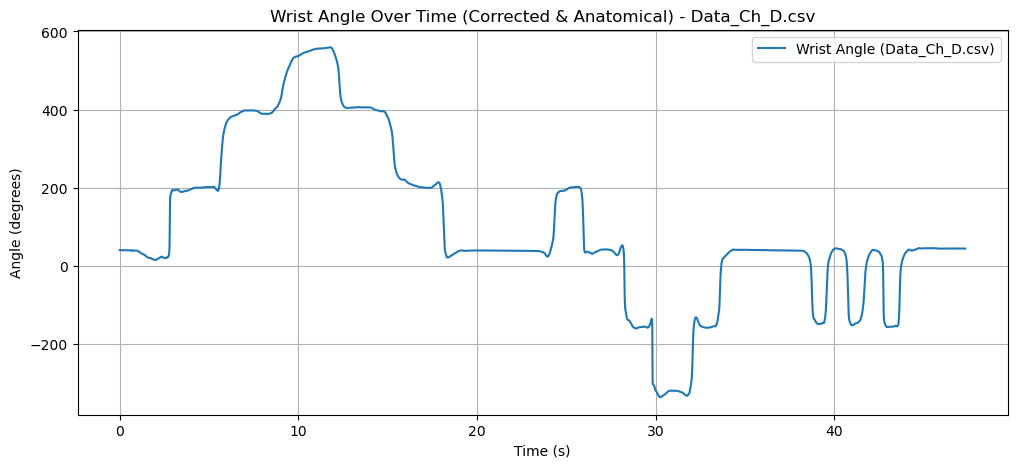

===== FILE: Data_Ch_D.csv =====
Min angle: -336.76925568226636
Max angle: 559.6281723034925


In [2]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Ch_D.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Ch_D.csv": 40,
  
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

In [4]:
# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)


    # ---------- STEP 2 : FIND K-PUSH and K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None
    for i, line in enumerate(lines):
        if "K-Push" in line and idx_push is None:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    if idx_push is None:
        print("❌ K-PUSH NOT FOUND")
        return None, None, None, None
    if idx_move is None:
        print("❌ K-MOVE NOT FOUND")
        return None, None, None, None

    # ---------- STEP 3 - SPLIT BLOCKS (ORDER INDEPENDENT) ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        move_lines = lines[idx_move:idx_push]
        push_lines = lines[idx_push:]


    # ---------- STEP 4: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
       try:
        header_idx_push = next(i for i, line in enumerate(push_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Push non trouvé")
        return None, None, None, None

    
    push_str = "".join(push_lines[header_idx_push:])
    df_push = pd.read_csv(StringIO(push_str), sep=r"\t|,", engine="python", on_bad_lines="skip")
    df_push = df_push.dropna(axis=1, how='all')
    df_push = df_push.rename(columns={"temps (seconde)": "time", "CHANNEL_1": "force"})
    if "time" in df_push.columns and "force" in df_push.columns:
        df_push = df_push[["time", "force"]]
        df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()
    else:
        df_push = pd.DataFrame()    


    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}
    for line in lines:
        if "Quaternion de base" in line:
            parts = line.strip().split("\t")
            if len(parts) < 5:
                parts = line.strip().split(",")
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue
            values = values[:4]
            if "S121577" in parts[0]:
                baseline["wrist"] = values
            elif "S121578" in parts[0]:
                baseline["shoulder"] = values



# ---------- STEP 6 - CLEAN K-MOVE ----------
    try:
        header_idx_move = next(i for i, line in enumerate(move_lines) if "temps" in line.lower())
    except StopIteration:
        print("❌ Header K-Move non trouvé")
        return df_push, pd.DataFrame(), pd.DataFrame(), baseline

    move_data_lines = move_lines[header_idx_move + 1:]
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")
        if len(row) < 2:
            row = line.strip().split(",")
        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)
    df_move = df_move.replace("", np.nan).dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce').ffill().bfill()

    # ---------- EXTRACT SENSORS ----------
    try:
        df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
        df_wrist.columns = ["time","qx","qy","qz","qw"]
        df_shoulder = df_move.iloc[:, [0,5,6,7,8]].copy()
        df_shoulder.columns = ["time","qx","qy","qz","qw"]
    except:
        df_wrist = pd.DataFrame()
        df_shoulder = pd.DataFrame()

    # ---------- RETURN ----------
    return df_push, df_wrist, df_shoulder, baseline
]


# ==========================================================
# MAIN SCRIPT
# ==========================================================
filename = ["Data_Gh_G"]  # liste des fichiers

results = {}

for file in filename:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)
    results[file] = {"push": df_push, "wrist": df_wrist, "shoulder": df_shoulder, "baseline": baseline}

    # ---------- FULL DISPLAY ----------
    print(f"\n===== FILE: {file} =====")
    print("\nK-Push:\n", df_push.head())
    print("\nWrist (S121577):\n", df_wrist.head())
    print("\nShoulder (S121578):\n", df_shoulder.head())
    print("\nBaseline wrist:", baseline.get("wrist", []))
    print("Baseline shoulder:", baseline.get("shoulder", []))
    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)




IndentationError: unindent does not match any outer indentation level (<string>, line 44)

In [14]:
import pandas as pd
import numpy as np
from io import StringIO
import os
## STEP 1: IMPORT LIBRARIES + CLEAN DATA  + DEFINE FUNCTIONS + CHECK FILES  + EXTRACT BASELINE VALUES

# ==========================================================
# FUNCTION: LOAD DATA FILE
# ==========================================================
def load_data(filename):
    """
    Load a data file from the ../data folder.

    Parameters:
        filename (str): name of the file (e.g. "Data_GG.csv")

    Returns:
        lines (list): all lines from the file
    """
    path = os.path.join("..", "data", filename)

    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    return lines


# ==========================================================
# FUNCTION: PROCESS ONE FILE
# ==========================================================
def process_file(filename):

    # ---------- STEP 1: LOAD FILE ----------
    lines = load_data(filename)

    # ---------- STEP 2: FIND K-PUSH AND K-MOVE BLOCKS ----------
    idx_push = None
    idx_move = None

    for i, line in enumerate(lines):
        if "K-Push" in line:
            idx_push = i
        if "K-Move" in line and idx_move is None:
            idx_move = i

    # ---------- STEP 3: SPLIT FILE ----------
    if idx_push < idx_move:
        push_lines = lines[idx_push:idx_move]
        move_lines = lines[idx_move:]
    else:
        push_lines = lines[idx_push:]
        move_lines = lines[idx_move:idx_push]

    # ---------- STEP 4: CLEAN K-PUSH ----------
    header_idx_push = next(i for i, line in enumerate(push_lines) if "temps (seconde)" in line)

    push_str = "".join(push_lines[header_idx_push:])

    df_push = pd.read_csv(
        StringIO(push_str),
        sep=r"\t|,",
        engine="python",
        on_bad_lines="skip"
    )

    df_push = df_push.dropna(axis=1, how='all')

    df_push = df_push.rename(columns={
        "temps (seconde)": "time",
        "CHANNEL_1": "force"
    })

    df_push = df_push[["time", "force"]]
    df_push = df_push.apply(pd.to_numeric, errors='coerce').dropna()

    # ---------- STEP 5: ROBUST BASELINE EXTRACTION ----------
    baseline = {"wrist": [], "shoulder": []}

    for line in move_lines:
        if "Quaternion de base" in line:

            # Try splitting with tab first
            parts = line.strip().split("\t")

            # If tab split fails → try comma
            if len(parts) < 5:
                parts = line.strip().split(",")

            sensor_name = parts[0]

            # Extract numeric values safely
            values = []
            for x in parts[1:]:
                try:
                    values.append(float(x))
                except:
                    continue

            # Keep only first 4 values (qx, qy, qz, qw)
            values = values[:4]

            # Assign values to correct sensor
            if "S121577" in sensor_name:
                baseline["wrist"] = values
            elif "S121578" in sensor_name:
                baseline["shoulder"] = values

    # ---------- FIND HEADER ----------
    header_idx_move = next(i for i, line in enumerate(move_lines) if "temps (seconde)" in line)

    move_data_lines = move_lines[header_idx_move + 1:]

    # ---------- PARSE DATA ----------
    split_rows = []
    for line in move_data_lines:
        row = line.strip().split("\t")

        if len(row) < 2:
            row = line.strip().split(",")

        split_rows.append(row)

    df_move = pd.DataFrame(split_rows)

    df_move = df_move.dropna(axis=1, how='all')
    df_move = df_move.apply(pd.to_numeric, errors='coerce')
    df_move = df_move.ffill().bfill()

    # ---------- STEP 6: EXTRACT SENSORS ----------
    df_wrist = df_move.iloc[:, [0,1,2,3,4]].copy()
    df_wrist.columns = ["time","qx","qy","qz","qw"]

    df_shoulder = df_move.iloc[:, [0,6,7,8,9]].copy()
    df_shoulder.columns = ["time","qx","qy","qz","qw"]

    # ---------- FINAL CHECK ----------
    print(f"\n===== FILE: {filename} =====")

    print("K-Push:\n", df_push.head())

    print("\nWrist (S121577):\n", df_wrist.head())

    print("\nShoulder (S121578):\n", df_shoulder.head())

    print("\nBaseline wrist:", baseline["wrist"])
    print("Baseline shoulder:", baseline["shoulder"])

    print("\nShapes:", df_push.shape, df_wrist.shape, df_shoulder.shape)

    return df_push, df_wrist, df_shoulder, baseline


# ==========================================================
# MAIN SCRIPT
# ==========================================================

# ---------- SELECT FILE(S) ----------
files = ["Data_Et_D.csv"]

# files = ["Data_droite.csv", "Data_GG.csv"]  # for multiple files

# ---------- PROCESS FILE(S) ----------
results = {}

for file in files:
    df_push, df_wrist, df_shoulder, baseline = process_file(file)

    results[file] = {
        "push": df_push,
        "wrist": df_wrist,
        "shoulder": df_shoulder,
        "baseline": baseline
    }


# ==========================================================
# EXAMPLES
# ==========================================================

# Example: access wrist data
# df_wrist_example = results["Data_GG.csv"]["wrist"]

# Example: compare datasets
# print(results["Data_droite.csv"]["wrist"].shape)
# print(results["Data_GG.csv"]["wrist"].shape)


===== FILE: Data_Et_D.csv =====
K-Push:
     time    force
0  0.000  0.96355
1  0.002  0.95785
2  0.004  0.95055
3  0.006  0.97225
4  0.008  0.94885

Wrist (S121577):
     time        qx        qy        qz        qw
0  0.000 -0.595032  0.070190 -0.090149  0.795471
1  0.008 -0.595022  0.070223 -0.090152  0.795499
2  0.016 -0.594989  0.070284 -0.090152  0.795526
3  0.024 -0.594987  0.070345 -0.090182  0.795523
4  0.032 -0.594984  0.070436 -0.090212  0.795519

Shoulder (S121578):
     time        qx        qy        qz        qw
0  0.000  0.016052 -0.673950  0.701599  0.230652
1  0.008  0.015961 -0.673933  0.701644  0.230687
2  0.016  0.015808 -0.673901  0.701672  0.230717
3  0.024  0.015656 -0.673901  0.701673  0.230717
4  0.032  0.015503 -0.673879  0.701681  0.230720

Baseline wrist: [-0.038, -0.686, 0.684, 0.245]
Baseline shoulder: [-0.599, 0.079, -0.087, 0.792]

Shapes: (35390, 2) (8845, 5) (8845, 5)


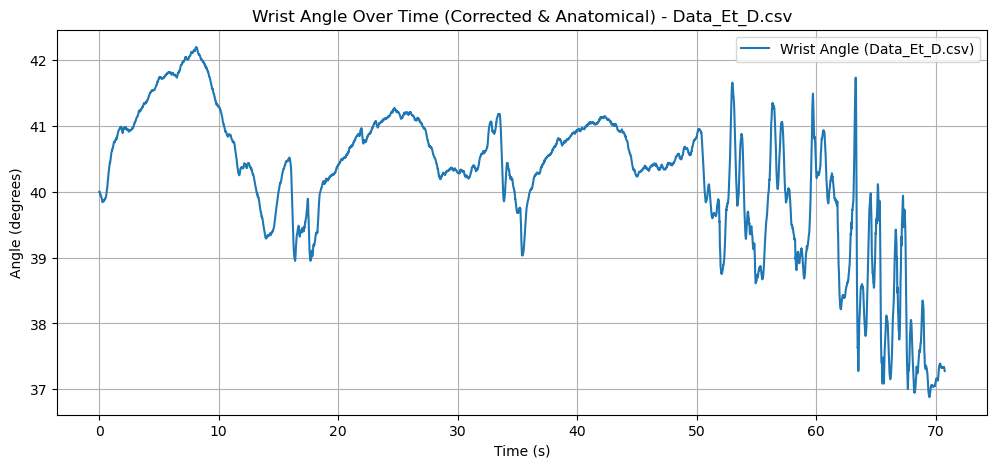

===== FILE: Data_Et_D.csv =====
Min angle: 36.88030087445236
Max angle: 42.19384939760003


In [16]:
## STEP 2 - CONVERT QUATERNION TO ANATOMICAL ANGLE + PLOT

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# FUNCTION: CONVERT QUATERNION TO ANATOMICAL ANGLE
# ==========================================================
def quaternion_to_angle_x_corrected(df_quat, baseline_deg):
    """
    Convert quaternion to anatomically meaningful wrist/elbow angle.

    Steps:
    1. Compute raw angle from quaternion
    2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
    3. Convert to degrees
    4. Recalibrate so that:
       - max flexion = baseline_deg (manual reference from video)
       - extension increases toward ~180°
    """

    # Extract quaternion components
    qx = df_quat["qx"].values
    qy = df_quat["qy"].values
    qz = df_quat["qz"].values
    qw = df_quat["qw"].values

    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed

    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat[["time"]].copy()
    df_angles["angle"] = angle_anatomical

    return df_angles


# ==========================================================
# MULTI-FILE PROCESSING
# ==========================================================
files = ["Data_Et_D.csv"]  # Example single file
# files = ["Data_droite.csv", "Data_GG.csv"]  # Multiple files

# Manual baseline angles for each file (from video analysis)
baseline_angles = {
    "Data_Et_D.csv": 40,
  
}

# Store results
angles_results = {}

for file in files:
    # Get wrist DataFrame from previous step (process_file)
    df_wrist = results[file]["wrist"]

    # Get manual baseline angle for this file
    manual_baseline = baseline_angles[file]

    # Convert quaternion → anatomical angle
    df_wrist_angles = quaternion_to_angle_x_corrected(df_wrist, manual_baseline)

    # Store results
    angles_results[file] = df_wrist_angles

    # ---------- PLOT ----------
    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())

In [20]:
#I want to convert quaternion to anatomically meaningful wrist angle. I want to do this by following these steps:
#1. Compute raw angle from quaternion
#2. Unwrap angle to avoid discontinuities (-180/+180 jumps)
#3. Convert to degrees
#4. Recalibrate so that:
#   - max flexion = baseline_deg (manual reference from video)
#   - extension increases toward ~180°  

# i want to do it with this file : Data_Et_D.csv and i want to do it for the wrist sensor (S121577) and i want to use the baseline values that are given in the file before the data of K-Move for this sensor. I want to check the range of angles to see if they are anatomically plausible. I want to plot the angle over time. I want to do this for all the files of all the patients.


    # ---------- STEP 1: RAW ANGLE (rad) ----------
    angle_raw = np.arctan2(
        2*(qw*qx + qy*qz),
        1 - 2*(qx**2 + qy**2)
    )   

    # ---------- STEP 2: UNWRAP ----------
    angle_unwrapped = np.unwrap(angle_raw)      

    # ---------- STEP 3: CONVERT TO DEGREES ----------
    angle_deg = np.degrees(angle_unwrapped)

    # ---------- STEP 4: ZERO-REFERENCE ----------
    angle_zeroed = angle_deg - angle_deg[0]

    # Invert direction if needed (flexion = small, extension = large)
    if np.mean(angle_zeroed) < 0:
        angle_zeroed = -angle_zeroed
    # ---------- STEP 5: APPLY MANUAL ANATOMICAL SCALE ----------
    angle_anatomical = angle_zeroed + baseline_deg

    # Store in DataFrame
    df_angles = df_quat["time"].copy()
    df_angles["angle"] = angle_anatomical   
    return df_angles


# I want to plot the angle over time for each file and check the range of angles to see if they are anatomically plausible. I want to do this for all the files of all the patients.

    # ---------- PLOT ----------


    plt.figure(figsize=(12,5))
    plt.plot(df_wrist_angles["time"], df_wrist_angles["angle"], label=f"Wrist Angle ({file})")
    plt.xlabel("Time (s)")
    plt.ylabel("Angle (degrees)")               
    plt.title(f"Wrist Angle Over Time (Corrected & Anatomical) - {file}")
    plt.legend()
    plt.grid(True)
    plt.show()      

    # ---------- CHECK RANGE ----------
    print(f"===== FILE: {file} =====")
    print("Min angle:", df_wrist_angles["angle"].min())
    print("Max angle:", df_wrist_angles["angle"].max())




IndentationError: unexpected indent (1584546059.py, line 13)